# Case 3: Vandalism on Wikipedia Classification Analysis

In [50]:
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv('/Users/mrlee/development/MSIS501/Data-Mining-And-Analytics/data/Wikipedia.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Vandal           3876 non-null   int64
 1   Minor            3876 non-null   int64
 2   LoggedIn         3876 non-null   int64
 3   HTTP             3876 non-null   int64
 4   NumWordsAdded    3876 non-null   int64
 5   NumWordsRemoved  3876 non-null   int64
dtypes: int64(6)
memory usage: 181.8 KB


In [52]:
df.head()

,Vandal,Minor,LoggedIn,HTTP,NumWordsAdded,NumWordsRemoved
0,0,1,1,1,96,0
1,0,1,1,0,3,1
2,0,0,1,0,0,4
3,0,1,0,0,10,92
4,0,1,1,1,94,10


## a) Exploring Dataset
### a.i) Number of cases of vandalism detected

In [53]:
# Count the number of Vandal in the dataset
num_van = df['Vandal'].value_counts()[1]
print("Number of vandalisms: ", num_van)

Number of vandalisms:  1815


### a.ii) Average number of words that added/removed

In [54]:
# Average number of words added
avg_words_added = df['NumWordsAdded'].mean()
print("Average number of words added: ", avg_words_added)

# Average number of words removed
avg_words_removed = df['NumWordsRemoved'].mean()
print("Average number of words removed: ", avg_words_removed)

Average number of words added:  4.050051599587204
Average number of words removed:  3.5128998968008256


### a.iii) Correlation Analysis with Vandal

In [55]:
# Correlation Analysis with Vandal
correlation = df.corr()
print(correlation['Vandal'])

Vandal             1.000000
Minor             -0.213995
LoggedIn          -0.429255
HTTP               0.151554
NumWordsAdded     -0.000729
NumWordsRemoved    0.036360
Name: Vandal, dtype: float64


The most positively correlated: HTTP (0.151554) </br>
The most negatively correlated: LoggedIn (-0.429255)

## b) Prepare Data and Check Baseline Accuracy

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Vandal'])
y = df['Vandal']

# Split data to training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Simple baseline method prediction that always predict "not vandal" (0)
baseline_pred = np.zeros(len(y_test))
baseline_acc = np.mean(baseline_pred == y_test)
print("Baseline accuracy: ", baseline_acc)


Baseline accuracy:  0.5442820292347378


## c) CART Model
### c.i) Plot CART tree

In [57]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Split train data
X_train_1, X_val, y_train_1, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

# min_samples_leaf hyperparameter
msl_param = [10, 50, 100]

# Build CART Model
ctree_10 = DecisionTreeClassifier(min_samples_leaf=msl_param[0])
ctree_50 = DecisionTreeClassifier(min_samples_leaf=msl_param[1])
ctree_100 = DecisionTreeClassifier(min_samples_leaf=msl_param[2])

# Fit the model
ctree_10.fit(X_train_1, y_train_1)
ctree_50.fit(X_train_1, y_train_1)
ctree_100.fit(X_train_1, y_train_1)

# Evaluate the model on the test set
y_pred = ctree_10.predict(X_val)
accuracy = np.mean(y_pred == y_val)
print("Accuracy of the ctree_10 model: ", accuracy)

y_pred = ctree_50.predict(X_val)
accuracy = np.mean(y_pred == y_val)
print("Accuracy of the ctree_50 model: ", accuracy)

y_pred = ctree_100.predict(X_val)
accuracy = np.mean(y_pred == y_val)
print("Accuracy of the ctree_100 model: ", accuracy)

Accuracy of the ctree_10 model:  0.7272727272727273
Accuracy of the ctree_50 model:  0.7199017199017199
Accuracy of the ctree_100 model:  0.7100737100737101


Accuracy of the ctree_10 model is the highest. So optimal min_samples_leaf is 10. 

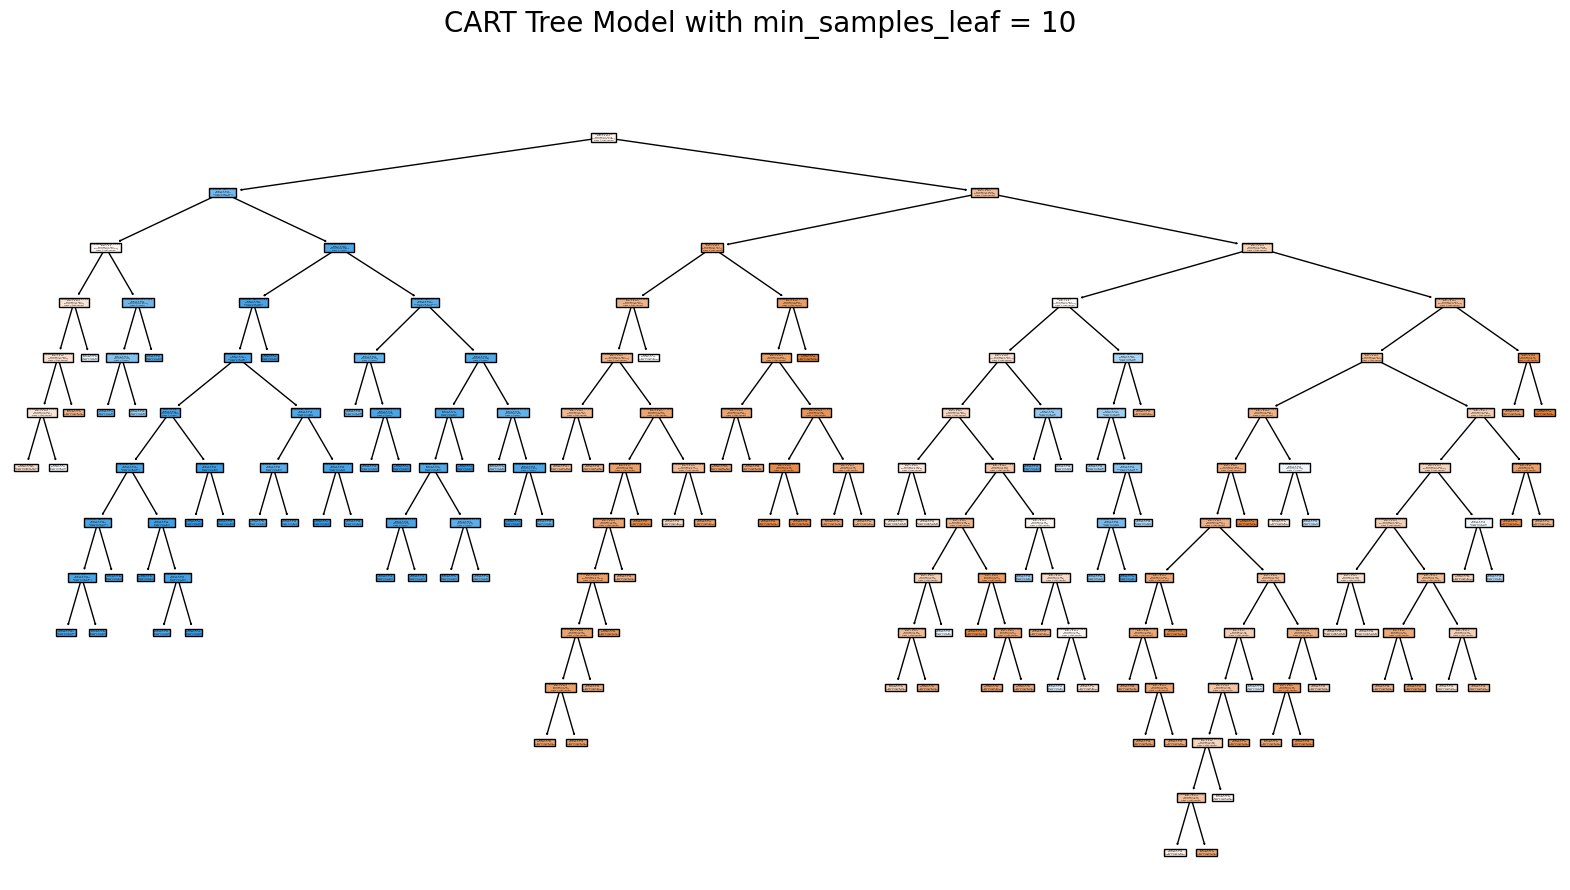

In [58]:
# Use the best model to predict the test set
ctree_10.fit(X_train, y_train)
y_pred = ctree_10.predict(X_test)

# Plot the best model
plt.figure(figsize=(20, 10))
plt.suptitle("CART Tree Model with min_samples_leaf = 10", fontsize=20)
plot_tree(ctree_10, feature_names=X.columns, class_names=['Not Vandal', 'Vandal'], filled=True)
plt.savefig("cart_tree_high_res.png", dpi=600)  # Save with high resolution
plt.show()

In [59]:
# Extract feature importances from the CART model
feature_importances = pd.Series(ctree_10.feature_importances_, index=X_train.columns)

# Sort the features by importance
significant_features = feature_importances.sort_values(ascending=False)

significant_features

LoggedIn           0.560756
NumWordsAdded      0.283403
NumWordsRemoved    0.110191
Minor              0.034830
HTTP               0.010820
dtype: float64

Variables used in the trees are: LoggedIn, NumWordsAdded, NumWordsRemoved, Minor, HTTP

Based on the tree, the top 3 variables that appeared closest to the root are: LoggedIn, NumWordsAdded, and NumWordsRemoved. 
I included a feature importance function that shows the significant features, sorted by significance, and this supported my answer that was derived from the plot. 

### c.ii) Compute Accuracy

In [60]:
# Calculate accuracy of the best model
accuracy = np.mean(y_pred == y_test)
print("Accuracy of the best model on the test set: ", accuracy)

Accuracy of the best model on the test set:  0.7497850386930353


## e) Business Implication

### e.i) Do you think the model you built could be useful to Wikipedia to detect vandalism? Why or why not?

I think the model built will be useful to Wikipedia to detect vandalism because comparing it with the baseline test, this model achieved higher accuracy, which means that it can identify potential vandalism better than random guessing. 

However, this model comes with limitation of false positive/negatives. Sometimes it might still miss certain cases but this can be resolved by manual review for those ambiguous classfications. Another point to make is vandalism might evolve over time so the model needs to be updated appropriately. 


### e.ii) If you could collect more data about the edits, what variables would you want? Why?

Additional variables:
- Editor reputation:
    This can contribute to 'how sure' an edit is considered vandalism based on the editor's reputation. 
- Edit time and length:
    Edits that are made during 'odd hours' may be correlated to vandalism. Or even short edits can also be correlated to vandalism. 
- Page Context:
    Some pages are more prone to attract vandalism perpetrators. 

With these additional variables, model could improve. 

### e.iii) The data used in this problem was collected from the page about Language. Do you think this model would easily extend to other pages? Why or why not?

This model may not easily extend to other pages due to differences in topics have differences in vandalism patterns from the variables collected. It would require retraining the model with specific pages for more accurate results. 